# Singular-protein reward trajectories: Spectral vs Linear vs Exclusion

Ported from `analyze_new_spectral.ipynb` (`display_res` example for the same seeded protein).
Paths updated for main directory `/u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup`.

In [35]:
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerPatch
from utils import get_eval_stats

MAIN_DIR = Path("/u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup")
EVAL_ROOT = MAIN_DIR / "DRAKES" / "drakes_protein" / "fmif" / "eval_results"
test_dir = str(EVAL_ROOT / "test") + "/"
valid_dir = str(EVAL_ROOT / "validation") + "/"
group1_dir = test_dir + "target/group1/"
FIG_DIR = MAIN_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

summary_func = np.mean

# Match landon_spex_scaling.ipynb publication style
NEURIPS_RC = {
    "figure.dpi": 180,
    "savefig.dpi": 400,
    "font.family": "DejaVu Sans",
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.05,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "grid.linewidth": 0.55,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
}
mpl.rcParams.update(NEURIPS_RC)

# Same ink weights as landon_spex_scaling.ipynb
LINE_W = 4.5
SPINE_LW = 3
MARKER_S = 11.0
FIGSIZE = (12, 4.0)  # ~2x landon single-panel (6, 3.5)

TRAJ_NAMES = ["ProxySPEX", "LASSO"]#, "Exclusion"]
# Matte, distinct hues (dusty teal / clay / muted violet)
TRAJ_COLORS = ["#2A9D8F", "#E09F3E", "#9B5DE5"]


class SquarePatchHandler(HandlerPatch):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        size = height
        x = xdescent + (width - size) / 2
        sq = Rectangle(
            (x, ydescent - 4.0),
            size,
            size,
            facecolor=orig_handle.get_facecolor(),
            edgecolor=orig_handle.get_edgecolor(),
            linewidth=orig_handle.get_linewidth(),
            transform=trans,
        )
        return [sq]


def style_ax(ax):
    ax.grid(True, which="major")
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(SPINE_LW)


def legend_handles(labels=TRAJ_NAMES, colors=TRAJ_COLORS):
    return [
        Patch(facecolor=color, edgecolor="none", linewidth=0, label=label)
        for color, label in zip(colors, labels)
    ]


def shared_legend(fig, labels=TRAJ_NAMES, colors=TRAJ_COLORS, **legend_kw):
    kw = dict(
        handles=legend_handles(labels, colors),
        handler_map={Patch: SquarePatchHandler()},
        frameon=False,
        borderpad=0.4,
        handlelength=1.0,
        handleheight=1.0,
        handletextpad=0.6,
        fontsize=18,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.22),
        ncol=3,
    )
    kw.update(legend_kw)
    return fig.legend(**kw)


def plot_traj_panel(ax, res, title, ylabel=None):
    traj_lst = []
    targets = ["spec_traj", "linear_traj", "ex_traj"]
    for t in targets:
        if t in res:
            traj_lst.append(res[t])
    its = np.arange(0, len(traj_lst[0]))
    for traj, name, color in zip(traj_lst, TRAJ_NAMES, TRAJ_COLORS):
        ax.plot(
            its,
            traj,
            linestyle="-",
            linewidth=LINE_W,
            color=color,
            marker=None,
            zorder=2,
            label=name,
        )
        ax.scatter(
            its,
            traj,
            s=MARKER_S**2,
            facecolors=color,
            edgecolors="white",
            linewidths=1.0,
            zorder=5,
            clip_on=False,
        )
    ax.set_xlabel("Feedback Iteration")
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(its)
    all_vals = np.concatenate([np.asarray(v) for v in traj_lst])
    y0, y1 = float(all_vals.min()), float(all_vals.max())
    pad = 0.05 * (y1 - y0 if y1 > y0 else 1.0)
    ax.set_ylim(y0 - pad, y1 + pad)
    style_ax(ax)


print("MAIN_DIR:", MAIN_DIR)
print("test_dir:", test_dir)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
MAIN_DIR: /u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup
test_dir: /u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup/DRAKES/drakes_protein/fmif/eval_results/test/


## Hardcoded same-seed example trajectories

One figure, single panel (`R6-560`) with a shared ProxySPEX / LASSO legend.

Saved PDF to: /u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup/figures/singular_protein_traj_comparison.pdf


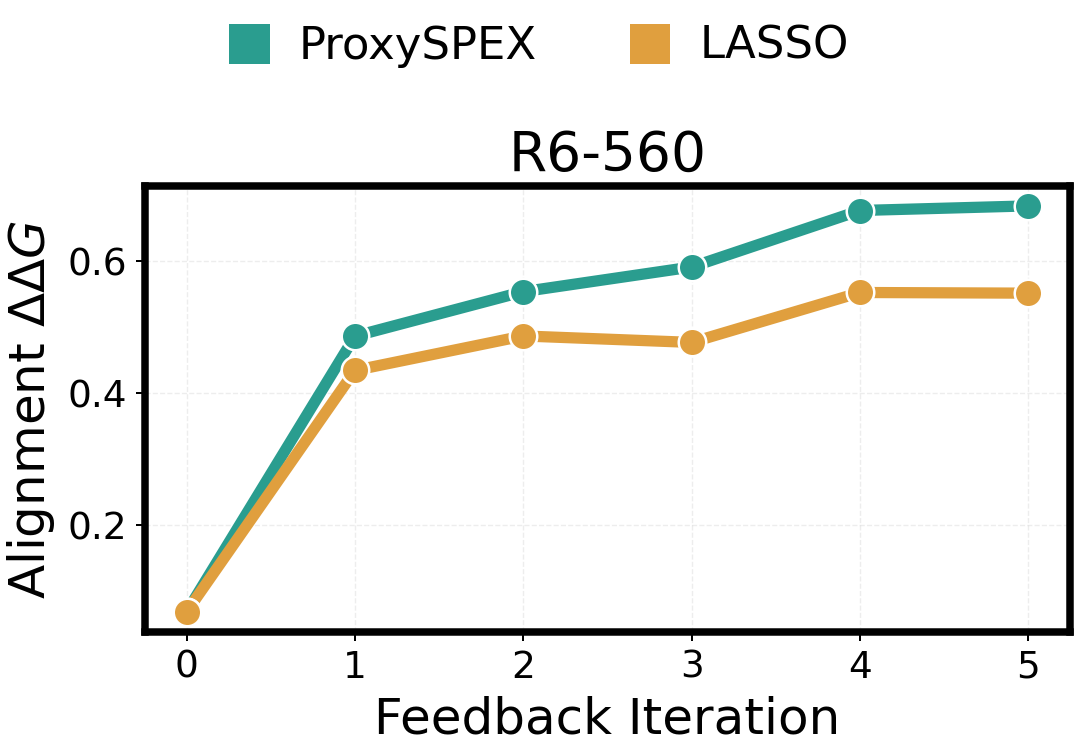

In [36]:
# res_r6 = {
#     "spec_traj": [0.5081, 0.5905, 0.6294, 0.6653, 0.6653, 0.675],
#     "linear_traj": [0.5081, 0.5684, 0.5684, 0.5813, 0.5813, 0.5813],
#     # "ex_traj": [0.5081, 0.5684, 0.5684, 0.5684, 0.5684, 0.5684],
# }
# res_2kru = {
#     "spec_traj": [0.5754, 0.6285, 0.6349, 0.6499, 0.6499, 0.6499],
#     "linear_traj": [0.5754, 0.6285, 0.6439, 0.6507, 0.6507, 0.6507],
#     # "ex_traj": [0.5754, 0.5979, 0.6349, 0.6349, 0.6349, 0.6349],
# }
res_r6 = {
    "spec_traj": [np.float64(0.0679), np.float64(0.4865), np.float64(0.5541), np.float64(0.5915), np.float64(0.6773), np.float64(0.6843)],
    "linear_traj": [np.float64(0.0679), np.float64(0.4345), np.float64(0.4868), np.float64(0.477), np.float64(0.5528), np.float64(0.5518)],
    # "ex_traj": [0.5081, 0.5684, 0.5684, 0.5684, 0.5684, 0.5684],
}
res_2kvv = {
    "spec_traj": [np.float64(-0.1766), np.float64(0.3299), np.float64(0.3596), np.float64(0.591), np.float64(0.6261), np.float64(0.6717)],
    "linear_traj": [np.float64(-0.1766), np.float64(0.1106), np.float64(0.3755), np.float64(0.571), np.float64(0.6129), np.float64(0.6203)],
    # "ex_traj": [0.5754, 0.5979, 0.6349, 0.6349, 0.6349, 0.6349],
}

with plt.rc_context(NEURIPS_RC):
    fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
    plot_traj_panel(ax, res_r6, "R6-560", ylabel=r"Alignment $\Delta\Delta G$")
    shared_legend(fig, ncol=2)
    save_path = FIG_DIR / "singular_protein_traj_comparison.pdf"
    fig.savefig(save_path, format="pdf")
    print(f"Saved PDF to: {save_path}")
    plt.show()
    plt.close(fig)


## Optional: rebuild trajectories from CSVs

Same two-panel layout (`2KRU`, `R6-560`) using Spectral / Linear / Exclusion CSVs from `eval_results`.


Saved PDF to: /u/sdickman/DRAKES/drakes_protein/BLISS_DRAKES_Backup/figures/singular_protein_traj_comparison_from_csv.pdf


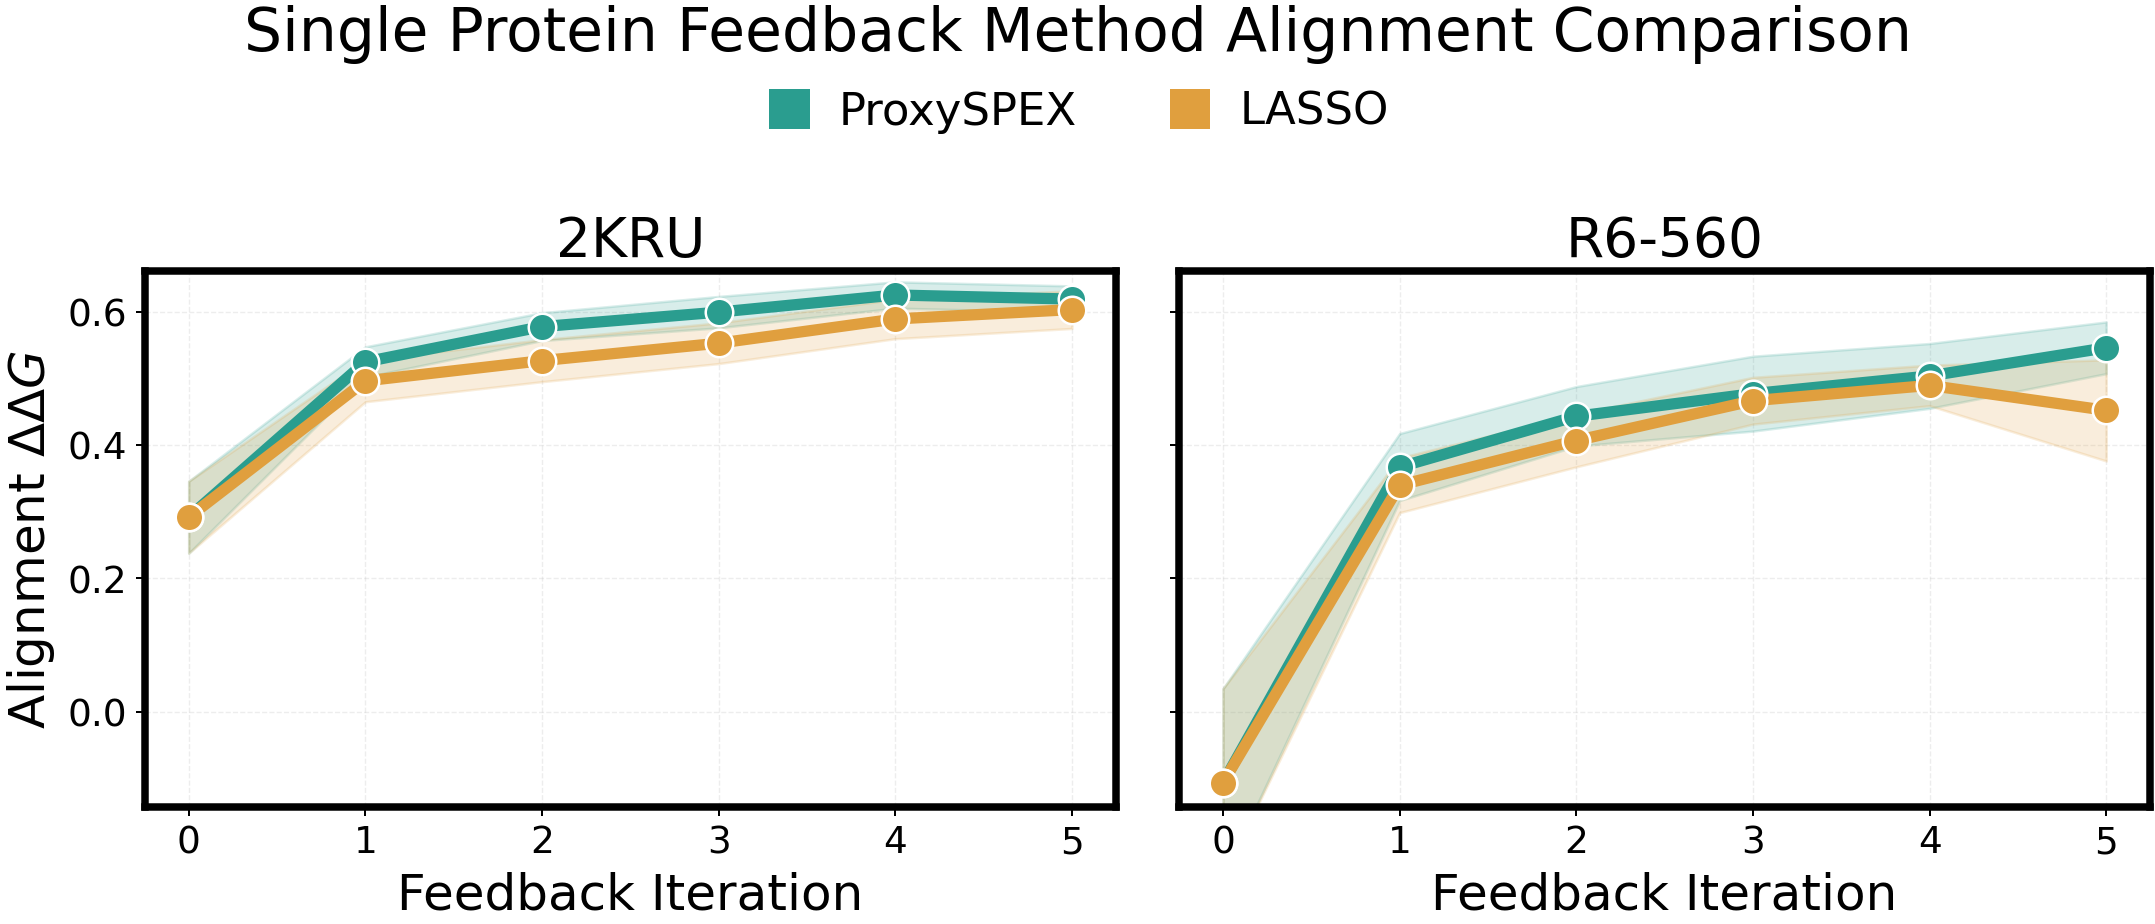

In [24]:
import ast


def calc_avg_traj(df, traj_col="spec_trajectory", target_protein=None):
    if target_protein is not None:
        df = df[df["protein_name"] == target_protein + ".pdb"]
    trajs = np.stack([np.asarray(ast.literal_eval(t), dtype=float) for t in df[traj_col]])
    avg = trajs.mean(axis=0)
    err = trajs.std(axis=0) / np.sqrt(max(len(trajs), 1))
    return avg, err


spec10_df = pd.read_csv(
    group1_dir
    + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192.csv"
)
lsq10_df = pd.read_csv(
    group1_dir
    + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=lasso_maxspecorder=10_masks=8192_lassolambda=0.0.csv"
)
ex10_df = pd.read_csv(
    group1_dir
    + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=10.csv"
)

dfs = [spec10_df, lsq10_df, ex10_df]
csv_panels = [
    ("2KRU", "2KRU"),
    ("r6_560_TrROS_Hall", "R6-560"),
]

with plt.rc_context(NEURIPS_RC):
    fig, axes = plt.subplots(
        1, 2, figsize=FIGSIZE, sharey=False, constrained_layout=True
    )
    fig.set_constrained_layout_pads(wspace=0.12)

    for ax, (protein_stem, title) in zip(axes, csv_panels):
        panel_vals = []
        for df, name, color in zip(dfs, TRAJ_NAMES, TRAJ_COLORS):
            traj, err = calc_avg_traj(df, "spec_trajectory", target_protein=protein_stem)
            its = np.arange(len(traj))
            panel_vals.append(traj)
            ax.plot(
                its,
                traj,
                linestyle="-",
                linewidth=LINE_W,
                color=color,
                marker=None,
                zorder=2,
                label=name,
            )
            ax.fill_between(its, traj - err, traj + err, color=color, alpha=0.18, zorder=1)
            ax.scatter(
                its,
                traj,
                s=MARKER_S**2,
                facecolors=color,
                edgecolors="white",
                linewidths=1.0,
                zorder=5,
                clip_on=False,
            )
        ax.set_xlabel("Feedback Iteration")
        ax.set_ylabel(r"Alignment $\Delta\Delta G$")
        ax.set_title(title)
        ax.set_xticks(its)
        all_vals = np.concatenate(panel_vals)
        y0, y1 = float(all_vals.min()), float(all_vals.max())
        pad = 0.05 * (y1 - y0 if y1 > y0 else 1.0)
        ax.set_ylim(y0 - pad, y1 + pad)
        style_ax(ax)

    fig.suptitle(
        "Single Protein Feedback Method Alignment Comparison",
        y=1.28,
        fontsize=24,
    )
    shared_legend(fig)
    save_path = FIG_DIR / "singular_protein_traj_comparison_from_csv.pdf"
    fig.savefig(save_path, format="pdf")
    print(f"Saved PDF to: {save_path}")
    plt.show()
    plt.close(fig)
